<a href="https://colab.research.google.com/github/emmanuelogbonna/FYP/blob/master/FNN_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================
# Import Libraries
# ================================
import pandas as pd
import numpy as np

import tensorflow as tf
# loading TensorFlow, which is like our main toolkit to build and train neural networks
from tensorflow.keras.models import Sequential
# accessing Keras, which is a high-level API inside TensorFlow.
# Sequential model is like stacking layers one after another
from tensorflow.keras.layers import Dense
#Dense layer is the core building block of neural networks where each neuron talks to all neurons in the next layer.

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score


In [2]:

# ================================
# Set seeds
# ================================
np.random.seed(42)
tf.random.set_seed(1)

# ================================
# Load Dataset
# ================================
data = pd.read_csv('Bank Churn.csv')

# ================================
# Features & Target
# ================================
X = data.drop(['RowNumber','CustomerId','Exited','Surname'], axis=1)
y = data['Exited']

# ================================
# Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


FileNotFoundError: [Errno 2] No such file or directory: 'Bank Churn.csv'

In [ ]:

# ================================
# Standardize numeric variables
# ================================
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'EstimatedSalary']

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# ================================
# Categorical encoding
# ================================
categorical_cols = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

# Align test columns with train
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# Convert to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)


In [ ]:

# ================================
# Build TensorFlow Model
# ================================
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)), # 32 neurons in first hidden layer,input_shape = number of input features
    Dense(16, activation='relu'), #This layer compresses and refines the learned information into 16 representations
    Dense(1, activation='sigmoid') # 1 neuron → binary classification sigmoid gives output between 0 and 1 (probability)

])

# Input Features → 32 Neurons → 16 Neurons → 1 Output (Probability)

# ================================
# Compile Model
# ================================
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# compile() configures the training process

# Optimizer is the driver, loss is the direction, and accuracy is just the scoreboard.

# ================================
# Train Model
# ================================
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    verbose=0 # try with 1
)

# For each epoch:
#     Split data into batches
#     For each batch:
#         Predict → Calculate loss → Update weights




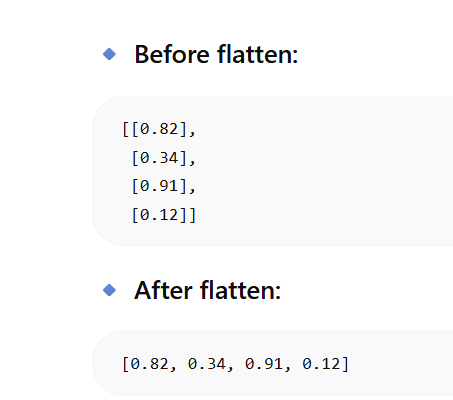

In [ ]:
# ================================
# Predictions
# ================================
y_pred_prob = model.predict(X_test).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

# ================================
# Evaluation
# ================================
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_prob))